# Kinetic analysis of enzymatic PET depolymerization — reproducible figures

**Companion notebook to** *"From Polyester Binding to Monomer Conversion: Three Stages of Enzymatic PET
Depolymerization Revealed by qNMR"* (Butenschön *et al.*).

This notebook fits a **minimal mass-conserving kinetic model** to the in-situ qNMR time courses and
regenerates the manuscript's kinetic figures from the raw `.xlsx` data. Running it top-to-bottom
reproduces:

* **Figure 1** — model fit to a representative run, and the enzyme-vs-autohydrolysis flux decomposition.
* **Figure 2** — the dual-enzyme design curve (terminal-rate target for a given TPA purity).
* **Figure 3** — the Arrhenius plot of the terminal rate constant.

All numerical results in the kinetic subsection derive from the cells below. The model, its assumptions,
and its identifiability limits are documented inline.

---

### The model

Six species are tracked (mM): accessible PET in terephthalate equivalents (*S*), the di-aromatic
intermediates **TET** (*D*) and **ETE/BHET** (*B*), the mono-aromatic **ET/MHET** (*M*), **TPA** (*T*),
and **EG** (*G*). Accessible PET is released from the surface at a first-order rate *k*ₛ and partitioned
among soluble products by a fingerprint (*f*). Each intermediate is then cleaved by a lumped first-order
step combining the **enzymatic** rate constant with the fixed **autohydrolysis** constant:

$$
\dot S=-k_sS,\quad
\dot D=\tfrac12 f_D k_sS-(k_D{+}k_{D,a})D,\quad
\dot B=f_B k_sS-(k_B{+}k_{B,a})B,
$$
$$
\dot M=f_M k_sS+(k_D{+}k_{D,a})D+(k_B{+}k_{B,a})B-(k_M{+}k_{M,a})M,
$$
$$
\dot T=f_T k_sS+(k_D{+}k_{D,a})D+(k_M{+}k_{M,a})M,\quad
\dot G=(k_B{+}k_{B,a})B+(k_M{+}k_{M,a})M.
$$

TET cleavage (TET→ET+TPA) retains the glycol on ET and releases **no EG**; ETE and ET cleavage each
release one EG. The ½ on TET's release reflects its two terephthalate units, making
*S*+2*D*+*B*+*M*+*T* exactly conserved. **EG is never fitted**, so it is an independent check on the
terminal flux.

> **Identifiability (read first).** The di-aromatic constants *k*_D and *k*_B are structurally
> degenerate (not separable from these data); *k*ₛ is only a lower bound when release outpaces sampling
> (high load / short runs); *k*_M is best constrained in runs reaching substantial conversion. We
> interpret only quantities robust to this — orderings, the terminal activation energy, the flux
> partition for the terminal step, and the dual-enzyme target — never the individual degenerate constants.

### Setup — mount Google Drive (Colab) and point to the data folder

In [1]:
# On Colab: run once to mount Drive, then put the .xlsx files in the DATA_DIR folder below.
try:
    from google.colab import drive
    drive.mount('/content/drive')
except Exception as e:
    print('Not on Colab (or mount skipped):', e)

DATA_DIR = "/content/drive/My Drive/qNMR_data/"   # <- folder containing the .xlsx files

Mounted at /content/drive


### Model, fitting, and plotting setup
Self-contained — no external modules required.

In [2]:
import numpy as np, pandas as pd, warnings
from scipy.integrate import solve_ivp
from scipy.optimize import least_squares, curve_fit
warnings.filterwarnings("ignore")

# ---- PNAS style + species colours (matched to Fig. 3) ----
import matplotlib as mpl, matplotlib.pyplot as plt
mpl.rcParams.update({
    "figure.dpi":140,"savefig.dpi":600,"savefig.bbox":"tight",
    "font.family":"sans-serif","font.sans-serif":["Arial","Helvetica","DejaVu Sans"],
    "font.size":7,"axes.titlesize":8,"axes.labelsize":7.5,"legend.fontsize":6.5,
    "xtick.labelsize":6.5,"ytick.labelsize":6.5,"axes.linewidth":0.6,
    "xtick.major.width":0.6,"ytick.major.width":0.6,"legend.frameon":False,
    "axes.spines.top":False,"axes.spines.right":False,
})
COL = {"TET":"#009060","ETE":"#E0A000","ET":"#C000C0","TPA":"#1878D8","EG":"#7a7a7a"}
PANEL = dict(fontsize=9,fontweight="bold",va="top",ha="left")
PNAS1, PNAS15, PNAS2 = 3.42, 4.49, 7.0   # inches: 1-col, 1.5-col, 2-col

IDX={"TET":1,"ETE":2,"ET":3,"TPA":4}; FIT=["TET","ETE","ET","TPA"]
# --- Autohydrolysis rate constants at 25 C (Fig. S22), held FIXED during enzymatic fitting ---
#   kD_a (TET): 5.75e-4 /min  -- well-resolved first-order decay fit
#   kB_a (ETE): 3.03e-4 /min  -- weakly constrained (low ETE, scatter)
#   kM_a (ET) : ET showed NO resolvable 25 C depletion; used as a CONSERVATIVE UPPER BOUND
#               (true value can only be smaller -> enzymatic share of ET can only be larger).
# kD_a and kB_a are FITTED from the Fig. S22 file in the cell below; kM_a is fixed as the bound.
KM_A_UPPER = 3.7e-6
AUTO = np.array([5.75e-4, 3.03e-4, KM_A_UPPER])   # placeholder; TET/ETE overwritten by the fit cell

def rhs(t,y,p,auto):
    S,D,B,M,T,G=y; vS=p[0]*S; fD,fB,fM,fT=p[4:8]
    kD=p[1]+auto[0]; kB=p[2]+auto[1]; kM=p[3]+auto[2]
    return [-vS, fD*vS/2-kD*D, fB*vS-kB*B, fM*vS+kD*D+kB*B-kM*M, fT*vS+kD*D+kM*M, kB*B+kM*M]

def simulate(p,t,S0,auto=AUTO):
    t=np.asarray(t,float)
    s=solve_ivp(rhs,(0,float(t.max())),[S0,0,0,0,0,0],t_eval=t,args=(p,auto),
                method="LSODA",rtol=1e-9,atol=1e-11)
    return s.y

def _sm4(a): z=np.array([a[0],a[1],a[2],0.]); z-=z.max(); e=np.exp(z); return e/e.sum()
def _unpack(th): ks,kD,kB,kM=np.exp(th[:4]); return np.array([ks,kD,kB,kM,*_sm4(th[4:7])])

def load_xlsx(path, rescale=True):
    raw=pd.read_excel(path,header=0).rename(columns={"t [min]":"t"})
    raw=raw.dropna(subset=["t"]).reset_index(drop=True)
    d={}
    for c in ["ETE","ET","TET","TPA"]:
        d[c]=pd.to_numeric(raw[c],errors="coerce").fillna(0).to_numpy() if c in raw else np.zeros(len(raw))
    t=raw["t"].to_numpy(float)
    o=np.argsort(t); t=t[o]
    for c in d: d[c]=d[c][o]
    Teq=2*d["TET"]+d["ETE"]+d["ET"]+d["TPA"]
    S0=float(np.median(Teq[-5:])) if len(Teq)>=5 else float(Teq.max())
    if rescale and len(Teq)>8:   # gentle post-peak drift rescale to conserve mass (long clean runs)
        pk=int(np.argmax(Teq))
        if pk<len(Teq)-3:
            tail=Teq[pk:]; corr=np.where(tail>0,Teq[pk]/np.maximum(tail,1e-9),1.0); corr=np.clip(corr,0.8,1.25)
            for c in d: d[c][pk:]=d[c][pk:]*corr
    return t,d,S0

def fit(t,d,S0,auto=AUTO,nstart=6,seed=0):
    # Weights: per-species scale weighting. Each species' residuals are divided by
    # w_s = 0.03 * max(species) + 0.05 mM, i.e. ~3% of that species' peak plus a small
    # floor. This balances the fit across species of very different magnitude (TPA vs ETE)
    # and prevents the largest species from dominating the objective.
    w={s:0.03*np.max(d[s])+0.05 for s in FIT}
    def resid(th):
        Y=simulate(_unpack(th),t,S0,auto)
        if Y.shape[1]!=len(t): return np.full(4*len(t),1e3)
        return np.concatenate([(Y[IDX[s]]-d[s])/w[s] for s in FIT])
    rng=np.random.default_rng(seed); best=None
    for i in range(nstart):
        if i==0: th0=np.array([np.log(0.02),np.log(0.05),np.log(0.1),np.log(0.003),0,0,0])
        else: th0=np.array([np.log(10**rng.uniform(-2.5,-.5)),np.log(10**rng.uniform(-2,0)),
                            np.log(10**rng.uniform(-2.5,0)),np.log(10**rng.uniform(-3.5,-1.5)),*rng.uniform(-2,2,3)])
        try:
            r=least_squares(resid,th0,method="trf",max_nfev=20000)
            if best is None or r.cost<best.cost: best=r
        except Exception: pass
    p=_unpack(best.x)
    return dict(p=p,ks=p[0],kD=p[1],kB=p[2],kM=p[3],f=p[4:8],res=best)

In [3]:
import os
def P(fn): return os.path.join(DATA_DIR, fn)
FILES = dict(
    fig2B = "04M_Buffer_2B_3A_PHL7.xlsx",                 # PHL7, 0.4 M (representative run)
    T = {50:"50C_Temp_3B_LCC-ICCG.xlsx", 60:"60C_Temp_3B_LCC-ICCG.xlsx", 70:"70C_Temp_3B_LCC-ICCG.xlsx"},
    load = {20:"20gkg_3C.xlsx", 200:"200gkg_3C.xlsx"},    # for the Ea-independent load check
    reactor = "Reactor_run_Excel.xlsx",                   # bench-scale reactor (dual-enzyme baseline)
    auto = "Autohydrolysis_Excel_FigS22.xlsx",            # 25 C oligomer-stability (autohydrolysis)
)
print("Data directory:", DATA_DIR)
print("Exists:", os.path.isdir(DATA_DIR))

Data directory: /content/drive/My Drive/qNMR_data/
Exists: True


### Autohydrolysis constants (fitted from Fig. S22, 25 °C)

The di-aromatic autohydrolysis constants are obtained by fitting first-order decays to the 25 °C
oligomer-stability time courses (TET and ETE). ET shows no resolvable 25 °C depletion, so `kM_a` is kept
fixed as a conservative upper bound. These 25 °C constants are held fixed in all enzymatic fits.

In [4]:
# ---- fit autohydrolysis (TET, ETE) from the 25 C stability data; kM_a stays as the upper bound ----
if os.path.exists(P(FILES['auto'])):
    a = pd.read_excel(P(FILES['auto']), header=0); a.columns=[str(c).strip() for c in a.columns]
    a = a.dropna(subset=['time [min]','ETE','TET']); tm = a['time [min]'].to_numpy(float)
    _dec = lambda t,C0,k: C0*np.exp(-k*t)
    kDa = curve_fit(_dec, tm, a['TET'].to_numpy(float), p0=[a['TET'].to_numpy(float)[0],1e-3],
                    bounds=([0,1e-6],[np.inf,1]))[0][1]
    kBa = curve_fit(_dec, tm, a['ETE'].to_numpy(float), p0=[a['ETE'].to_numpy(float)[0],1e-3],
                    bounds=([0,1e-6],[np.inf,1]))[0][1]
    AUTO = np.array([kDa, kBa, KM_A_UPPER])
    print(f"autohydrolysis @25 C (fitted): kD_a(TET)={kDa:.3e}  kB_a(ETE)={kBa:.3e}  min^-1;  "
          f"kM_a(ET) fixed at upper bound {KM_A_UPPER:.1e}")
else:
    print("Fig. S22 file not found -> using fallback AUTO =", AUTO)

autohydrolysis @25 C (fitted): kD_a(TET)=5.750e-04  kB_a(ETE)=3.032e-04  min^-1;  kM_a(ET) fixed at upper bound 3.7e-06


## Figure 1 — Model fit and enzyme-vs-autohydrolysis flux decomposition

**(A)** The mass-conserving model (lines) fitted to the measured soluble-product mol% (open circles) for
a representative run (PHL7, 0.4 M KPB). A single parameter set captures the rise and fall of the
intermediates and the monotonic approach of TPA.

**(B)** Enzymatic share of each cleavage step, obtained by **integrating the enzymatic and autohydrolytic
fluxes** over the reaction. Autohydrolysis is known only at 25 °C (Fig. S22); its activation energy
cannot be determined from one temperature, so instead of assuming a value we extrapolate the 25 °C
constants to 65 °C across the **full plausible range (40–100 kJ mol⁻¹)** and show the result versus that
assumption. The terminal **ET→TPA** step (solid) stays overwhelmingly enzymatic throughout; the
di-aromatic steps (dashed) are **indicative only** — sensitive both to the unknown *E*ₐ and to the
*k*_D/*k*_B degeneracy.

fitted (representative run): k_M=0.00180  k_D=0.0653  k_B=0.2198 min^-1
enzymatic share of ET flux:  99% (Ea=40) ... 80% (Ea=100)


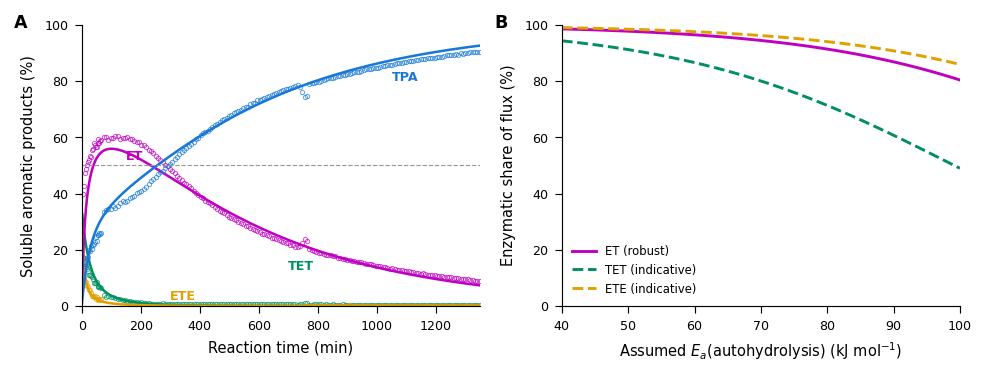

In [5]:
# ---- Figure 1 ----
fig,ax=plt.subplots(1,2,figsize=(PNAS2,2.7))

# (A) representative fit, mol%
t,d,S0 = load_xlsx(P(FILES['fig2B'])); r = fit(t,d,S0)
tf=np.linspace(0,t.max(),1500); Y=simulate(r['p'],tf,S0)
den_d=np.maximum(2*d['TET']+d['ETE']+d['ET']+d['TPA'],1e-9)
den_f=np.maximum(2*Y[1]+Y[2]+Y[3]+Y[4],1e-9)
for sp,yi in [('TET',1),('ETE',2),('ET',3),('TPA',4)]:
    ax[0].plot(t,100*d[sp]/den_d,'o',ms=2.2,mfc='none',mec=COL[sp],mew=0.5,alpha=.7)
    ax[0].plot(tf,100*Y[yi]/den_f,'-',color=COL[sp],lw=1.3)
ax[0].axhline(50,ls='--',color='0.6',lw=0.6)
for sp,xx,yy in [('ET',150,52),('TPA',1050,80),('TET',700,13),('ETE',300,2)]:
    ax[0].text(xx,yy,sp,color=COL[sp],fontsize=6.5,fontweight='bold')
ax[0].set_xlim(0,t.max()); ax[0].set_ylim(0,100)
ax[0].set_xlabel('Reaction time (min)'); ax[0].set_ylabel('Soluble aromatic products (%)')
ax[0].text(-0.17,1.04,'A',transform=ax[0].transAxes,**PANEL)

# (B) flux decomposition
Rg=8.314; Tref=298.15; Trun=338.15
kE={'TET':r['kD'],'ETE':r['kB'],'ET':r['kM']}; kA={'TET':AUTO[0],'ETE':AUTO[1],'ET':AUTO[2]}
Ea=np.linspace(40,100,120)
for sp in ['ET','TET','ETE']:
    sh=[100*kE[sp]/(kE[sp]+kA[sp]*np.exp(-E*1e3/Rg*(1/Trun-1/Tref))) for E in Ea]
    ax[1].plot(Ea,sh,'-' if sp=='ET' else '--',color=COL[sp],lw=1.5,
               label=('ET (robust)' if sp=='ET' else f'{sp} (indicative)'))
ax[1].set_ylim(0,100); ax[1].set_xlim(40,100)
ax[1].set_xlabel('Assumed $E_a$(autohydrolysis) (kJ mol$^{-1}$)')
ax[1].set_ylabel('Enzymatic share of flux (%)'); ax[1].legend(loc='lower left',fontsize=6)
ax[1].text(-0.17,1.04,'B',transform=ax[1].transAxes,**PANEL)

fig.tight_layout(w_pad=1.6)
fig.savefig('Fig_kinetic_1.png'); fig.savefig('Fig_kinetic_1.pdf')
print(f"fitted (representative run): k_M={r['kM']:.5f}  k_D={r['kD']:.4f}  k_B={r['kB']:.4f} min^-1")
print("enzymatic share of ET flux:  %.0f%% (Ea=40) ... %.0f%% (Ea=100)"%(
    100*r['kM']/(r['kM']+AUTO[2]*np.exp(-40e3/Rg*(1/Trun-1/Tref))),
    100*r['kM']/(r['kM']+AUTO[2]*np.exp(-100e3/Rg*(1/Trun-1/Tref)))))
plt.show()

**Assumption-free confirmation.** The enzymatic nature of the terminal step does not rely on any
autohydrolysis assumption: the ET disappearance rate *increases* with enzyme loading, whereas a
spontaneous process would be independent of enzyme concentration.

In [6]:
# ET post-peak decay rate vs enzyme load (model-free)
for L in [20,200]:
    t,d,S0=load_xlsx(P(FILES['load'][L]),rescale=False); ET=d['ET']; i=int(np.argmax(ET)); tp,Ep=t[i:],ET[i:]
    p,_=curve_fit(lambda x,A,k,C:A*np.exp(-k*(x-tp[0]))+C, tp,Ep,
                  p0=[Ep[0]-Ep[-1],.02,Ep[-1]],bounds=([0,1e-4,0],[100,1,50]),maxfev=20000)
    print(f"  ET decay rate at {L:>3} g/kg: {p[1]:.3f} min^-1   (autohydrolysis at 25 C: {AUTO[2]:.2e})")

  ET decay rate at  20 g/kg: 0.038 min^-1   (autohydrolysis at 25 C: 3.70e-06)
  ET decay rate at 200 g/kg: 0.072 min^-1   (autohydrolysis at 25 C: 3.70e-06)


### Uncertainty — residual bootstrap

The robustness of the rate ordering (ET→TPA as the slowest resolvable step) is assessed by
**residual bootstrap resampling** of the representative fit. Procedure, as implemented below:

* **Replicates:** `N_BOOT` resamples (200 by default; raise to 500–1000 for final results).
* **Resampling strategy:** model residuals (data − fitted trajectory) are resampled **with
  replacement**, added back to the fitted trajectories, and the full model is refitted.
* **Non-convergent fits:** resamples that fail to integrate/optimize, or return non-finite rate
  constants, are discarded; the converged count is reported.
* **Intervals:** 2.5/97.5 percentiles of the converged constants give 95% confidence intervals, and
  the fraction of resamples in which ET→TPA is slowest quantifies the robustness of that assignment.

This is the "residual bootstrap resampling" analysis referenced in the Methods. The wide
`k_B` interval relative to the tight `k_M` interval also makes the `k_D`/`k_B` degeneracy explicit.


In [11]:
N_BOOT = 200   # raise to 200-1000 for final results

t,d,S0 = load_xlsx(P(FILES['fig2B'])); r0 = fit(t,d,S0)
Y0 = simulate(r0['p'], t, S0)                      # fitted trajectories at data times
fitted = {s: Y0[IDX[s]] for s in FIT}
resid  = {s: d[s]-fitted[s] for s in FIT}          # residuals per species

rng = np.random.default_rng(0)
rec = {k:[] for k in ['ks','kD','kB','kM']}; slowest=[]; nconv=0
for b in range(N_BOOT):
    dd = {}
    for s in FIT:
        idx = rng.integers(0, len(t), len(t))      # resample residuals with replacement
        dd[s] = np.maximum(fitted[s] + resid[s][idx], 0.0)
    try:
        rb = fit(t, dd, S0, nstart=3, seed=b)
    except Exception:
        continue
    # keep only sane fits
    if not np.all(np.isfinite([rb['ks'],rb['kD'],rb['kB'],rb['kM']])): continue
    nconv += 1
    for k in rec: rec[k].append(rb[k])
    # which ENZYMATIC conversion step is slowest?
    ks_ = {'TET(k_D)':rb['kD'],'ETE(k_B)':rb['kB'],'ET(k_M)':rb['kM']}
    slowest.append(min(ks_, key=ks_.get))

import collections
counts = collections.Counter(slowest)
print(f"bootstrap: {nconv}/{N_BOOT} fits converged")
for k in ['ks','kD','kB','kM']:
    a=np.array(rec[k]); lo,hi=np.percentile(a,[2.5,97.5])
    print(f"  {k:3s}: median={np.median(a):.5f}  95% CI [{lo:.5f}, {hi:.5f}]")
frac = 100*counts.get('ET(k_M)',0)/max(nconv,1)
print(f"\nET->TPA (k_M) identified as the slowest enzymatic step in {frac:.0f}% of converged resamples")
print("ordering of 'slowest step' across resamples:", dict(counts))

bootstrap: 200/200 fits converged
  ks : median=0.00856  95% CI [0.00825, 0.00897]
  kD : median=0.04963  95% CI [0.04520, 0.05368]
  kB : median=0.23123  95% CI [0.02650, 0.42404]
  kM : median=0.00182  95% CI [0.00176, 0.00187]

ET->TPA (k_M) identified as the slowest enzymatic step in 100% of converged resamples
ordering of 'slowest step' across resamples: {'ET(k_M)': 200}


## Figure 2 — Dual-enzyme design curve: purity, not throughput

A dedicated MHET-hydrolysing activity acts on the rate-limiting ET→TPA step, modelled as an increase in
*k*_M. We simulate the reactor process and read the time to reach 95 mol% TPA **purity** as *k*_M is
increased.

Two regimes appear. **Purity** improves steadily as the terminal step is accelerated — reaching 95% TPA
within 6 h requires *k*_M of order **0.05 min⁻¹**. **Throughput**, however — how fast PET is solubilised
— is set by surface release and is *unaffected* by the added activity (horizontal "release floor"),
because an MHET-hydrolase acts on dissolved ET, not solid PET. A second enzyme therefore buys product
**purity**, not faster PET breakdown.

> Within-model extrapolation: the robust messages are the purity-vs-throughput distinction and the
> **order of magnitude** of the required terminal rate; the exact fold-increase depends on the (soft)
> reactor baseline *k*_M.

**Reactor baseline fit.** The dual-enzyme analysis extrapolates from the bench-scale reactor run
(Fig. 5; LCC ICCG, 100 g L⁻¹). The reactor qNMR series is sparse (11 points, reverse time order) and
contains isophthalate species (ITA, EG-ITA) and no detectable ETE; we therefore fit a reduced
`S → TET → ET → TPA` model to its TET, ET and TPA trajectories to obtain the baseline constants used
below. These are effective, weakly-constrained values — consistent with treating the dual-enzyme result
as an order-of-magnitude, within-model extrapolation.

In [12]:
# ---- Reactor baseline fit (replaces hard-coded constants) ----
def fit_reactor(path):
    raw = pd.read_excel(path, header=0); raw.columns=[str(c).strip() for c in raw.columns]
    q = raw[['time','TET','EG-ITA','ET','ITA','TPA']].copy()
    q['time'] = pd.to_numeric(q['time'], errors='coerce')
    q = q.dropna(subset=['time']).sort_values('time').reset_index(drop=True)
    for col in ['TET','EG-ITA','ET','ITA','TPA']: q[col]=pd.to_numeric(q[col],errors='coerce').fillna(0.0)
    tR = q['time'].to_numpy(float)
    # lump the isophthalate co-products onto the matching pools (keeps terephthalate-equiv mass):
    D = q['TET'].to_numpy(float)                       # di-aromatic
    M = (q['ET'] + q['EG-ITA']).to_numpy(float)        # mono-aromatic (+ EG-isophthalate)
    T = (q['TPA'] + q['ITA']).to_numpy(float)          # diacid (+ isophthalic acid)
    S0R = float(np.median((2*D + M + T)[-3:]))         # late-time T-equivalent plateau
    def simR(p,tt):
        ks,kD,kM,fD,fM = p
        def rr(u,y):
            S,Dv,Mv,Tv=y; v=ks*S
            return [-v, fD*v/2-kD*Dv, fM*v+kD*Dv-kM*Mv, (1-fD-fM)*v+kD*Dv+kM*Mv]
        s=solve_ivp(rr,(0,tt.max()),[S0R,0,0,0],t_eval=tt,method='LSODA',rtol=1e-7,atol=1e-9)
        return np.nan_to_num(s.y)
    wR=[0.05*D.max()+.5, 0.05*M.max()+.5, 0.05*T.max()+.5]
    def residR(p):
        if min(p)<0 or p[3]+p[4]>1: return np.full(3*len(tR),1e3)
        Y=simR(p,tR); return np.concatenate([(Y[1]-D)/wR[0],(Y[2]-M)/wR[1],(Y[3]-T)/wR[2]])
    best=None
    for i in range(40):
        rng=np.random.default_rng(i)
        g=[10**rng.uniform(-3,-1.5),10**rng.uniform(-3,-1),10**rng.uniform(-3.5,-2),*rng.dirichlet([1,1,1])[:2]] if i else [0.01,0.02,0.001,0.3,0.4]
        try:
            r=least_squares(residR,g,bounds=([1e-5,1e-5,1e-5,0,0],[1,2,0.1,0.9,0.9]),max_nfev=30000)
            if best is None or r.cost<best.cost: best=r
        except Exception: pass
    ks,kD,kM,fD,fM=best.x
    return ks,kD,kM,fD,fM,S0R

ks_r,kD_r,kM_r,fD_r,fM_r,S0R = fit_reactor(P(FILES['reactor']))
print(f"reactor baseline fit: k_s={ks_r:.4f}  k_D={kD_r:.4f}  k_M={kM_r:.5f}  f_D={fD_r:.2f}  f_M={fM_r:.2f}  S0R={S0R:.0f} mM")

reactor baseline fit: k_s=0.0040  k_D=0.0011  k_M=0.00137  f_D=0.08  f_M=0.54  S0R=129 mM


to reach 95% TPA purity in 6 h: terminal rate must increase ~37x (k_M ~ 0.051/min, t_1/2 ~ 14 min)
release-limited throughput floor (95% dissolution): ~12 h, independent of k_M


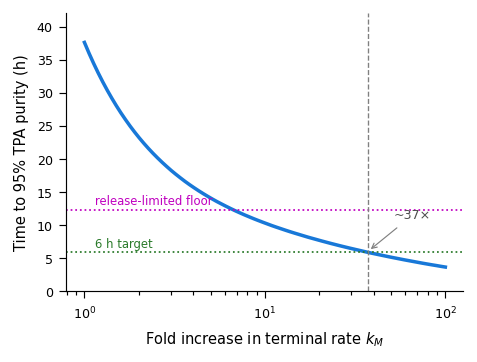

In [13]:
from scipy.integrate import solve_ivp
def sim_dual(kM,tt):
    def f(u,y):
        S,D,M,T=y; v=ks_r*S
        return [-v, fD_r*v/2-kD_r*D, fM_r*v+kD_r*D-kM*M, (1-fD_r-fM_r)*v+kD_r*D+kM*M]
    s=solve_ivp(f,(0,tt.max()),[S0R,0,0,0],t_eval=tt,method='LSODA',rtol=1e-7,atol=1e-9)
    return np.nan_to_num(s.y)
def t_to_purity(kM,target=95.0):
    tt=np.linspace(0,2880,6000); Y=sim_dual(kM,tt); ms=np.maximum(Y[1]+Y[2]+Y[3],1e-9)
    p=100*Y[3]/ms; return tt[np.argmax(p>=target)]/60 if p.max()>=target else np.nan

alphas=np.logspace(0,2,80); t95=np.array([t_to_purity(a*kM_r) for a in alphas])
t_rel95=-np.log(0.05)/ks_r/60
ok=np.where(t95<=6)[0]; a_need=alphas[ok[0]] if len(ok) else np.nan; kM_target=a_need*kM_r

fig,ax=plt.subplots(1,1,figsize=(PNAS1,2.6))
ax.semilogx(alphas,t95,'-',color=COL['TPA'],lw=1.8)
ax.axhline(6,ls=':',color='#2a7a2a',lw=0.9); ax.text(1.15,6.6,'6 h target',color='#2a7a2a',fontsize=6)
ax.axhline(t_rel95,ls=':',color=COL['ET'],lw=0.9); ax.text(1.15,t_rel95+0.7,'release-limited floor',color=COL['ET'],fontsize=6)
if np.isfinite(a_need):
    ax.axvline(a_need,ls='--',color='0.5',lw=0.7)
    ax.annotate(f'~{a_need:.0f}×',xy=(a_need,6),xytext=(a_need*1.4,11),fontsize=6.5,color='0.3',
                arrowprops=dict(arrowstyle='->',color='0.5',lw=0.6))
ax.set_xlabel('Fold increase in terminal rate $k_M$'); ax.set_ylabel('Time to 95% TPA purity (h)')
ax.set_ylim(0,42)
fig.tight_layout(); fig.savefig('Fig_kinetic_2.png'); fig.savefig('Fig_kinetic_2.pdf')
print(f"to reach 95% TPA purity in 6 h: terminal rate must increase ~{a_need:.0f}x "
      f"(k_M ~ {kM_target:.3f}/min, t_1/2 ~ {np.log(2)/kM_target:.0f} min)")
print(f"release-limited throughput floor (95% dissolution): ~{t_rel95:.0f} h, independent of k_M")
plt.show()

## Figure 3 — Temperature dependence of the terminal step

The terminal rate constant *k*_M fitted at 50, 60 and 70 °C follows an Arrhenius dependence, giving an
**apparent activation energy of ~60–65 kJ mol⁻¹** for the rate-limiting ET→TPA step. A
model-independent estimate from the reported t₅₀ values over the same three temperatures agrees (dashed).

> **Important limitation.** This rests on only **three temperatures**: the value is an *apparent,
> effective* activation energy over a narrow 20 °C window; the linearity of the Arrhenius relation
> cannot be tested and a meaningful uncertainty cannot be assigned. The t₅₀-based estimate uses the same
> three runs, so it is an **internal consistency check, not independent validation**. The magnitude is in
> the range expected for a chemically-controlled enzymatic step (rather than diffusion-limited),
> consistent with the terminal cleavage being rate-determining — but the number itself is not
> interpreted mechanistically. A fourth temperature (same enzyme batch) would be needed to test the
> Arrhenius assumption.

E_a(k_M fit) = 60 kJ/mol  (R2=0.991); E_a(t50, model-free) = 65 kJ/mol
-> report as ~60-65 kJ/mol; effective value, 3 temperatures, internal-consistency check only.


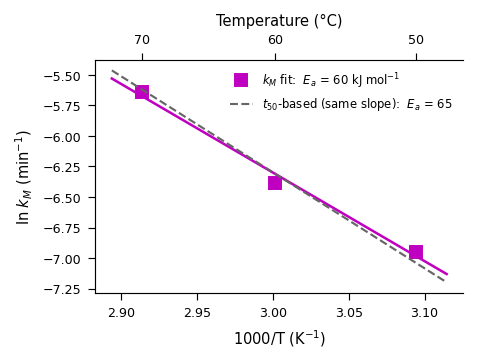

In [14]:
# ---- Figure S: Arrhenius of the terminal rate ----
Rg=8.314
kM_T={}
for T in [50,60,70]:
    t,d,S0=load_xlsx(P(FILES['T'][T])); kM_T[T]=fit(t,d,S0)['kM']
x=1000/(np.array([50,60,70])+273.15); y=np.log([kM_T[T] for T in [50,60,70]])
m,b=np.polyfit(x,y,1); Ea=-m*Rg; r2=1-np.sum((y-(m*x+b))**2)/np.sum((y-y.mean())**2)

# model-free t50 line (reported t50: 516/324/124 min)
t50=np.array([516.,324.,124.]); yt=np.log(np.log(2)/t50)
mt,bt=np.polyfit(x,yt,1); Ea_t=-mt*Rg
# shift t50 line onto the k_M intercept for visual comparison of SLOPE
offset=np.mean(y)-np.mean(mt*x+bt)

fig,ax=plt.subplots(1,1,figsize=(PNAS1,2.6))
xx=np.linspace(x.min()-.02,x.max()+.02,50)
ax.plot(x,y,'s',color=COL['ET'],ms=6,label=f'$k_M$ fit:  $E_a$ = {Ea:.0f} kJ mol$^{{-1}}$')
ax.plot(xx,m*xx+b,'-',color=COL['ET'],lw=1.3)
ax.plot(xx,mt*xx+bt+offset,'--',color='0.4',lw=1.1,label=f'$t_{{50}}$-based (same slope):  $E_a$ = {Ea_t:.0f}')
ax.set_xlabel('1000/T (K$^{-1}$)'); ax.set_ylabel('ln $k_M$ (min$^{-1}$)')
sec=ax.secondary_xaxis('top',functions=(lambda x:1000/x-273.15,lambda T:1000/(T+273.15)))
sec.set_xlabel('Temperature (°C)'); sec.set_xticks([50,60,70])
ax.legend(loc='upper right',fontsize=6)
fig.tight_layout(); fig.savefig('Fig_kinetic_S.png'); fig.savefig('Fig_kinetic_S.pdf')
print(f"E_a(k_M fit) = {Ea:.0f} kJ/mol  (R2={r2:.3f}); E_a(t50, model-free) = {Ea_t:.0f} kJ/mol")
print("-> report as ~60-65 kJ/mol; effective value, 3 temperatures, internal-consistency check only.")
plt.show()

---
### Notes on reproducibility

* All figures are written to the working directory as both `.png` (600 dpi) and `.pdf`.
* Autohydrolysis constants (`AUTO`) are fixed from the 25 °C oligomer-stability experiment (Fig. S22);
  `kM_a` is at/below that experiment's detection limit and is treated as a conservative upper bound.
* The reactor parameters in Figure 2 are from the bench-scale run fit; the dual-enzyme analysis is a
  within-model extrapolation (no product inhibition or protein-load effects are modelled).
* Fitted constants on the degenerate `k_D`/`k_B` directions are not interpreted individually.